# Clustering in Scanpy

In [37]:
# This cell is labelled 'paramters' to work with papermill remotely
# Papermill will overwite the default local plate value below with whatever is passed to 
# the -p flag in the snakerule shell script
#os.system("conda activate eqtl_study") use this locally if using VScode
plate = 'plate1'
plate = globals().get("plate")
print(f"Processing plate: {plate}")

Processing plate: plate1


In [38]:
# Import custom utility packages, lists and functions
import sys
import os
if os.path.exists('/scratch/'):
    root_dir = '/scratch/c.c1477909/eQTL_study_2025/'
else:
    root_dir = '/Users/darren/Desktop/eQTL_study_2025/'
        
sys.path.append(root_dir + 'workflow/scripts/')

from init_env import *
from anndata_utils import *
from gene_lists import *

# Set variables
resolutions = [0.3] # This takes a while per res
batch_col = 'plate' # Should we set to plate and sample??
run_genes_in_smpl_filter = True

2025-01-24 15:23:05,460 - INFO - Plate variable detected: plate1
2025-01-24 15:23:05,462 - INFO - Processing plate: plate1



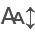

2025-01-24 15:23:05,480 - INFO - Script initialized. Root directory: /Users/darren/Desktop/eQTL_study_2025/
2025-01-24 15:23:05,481 - INFO - Parse directory: /Users/darren/Desktop/eQTL_study_2025/results/02PARSE/
2025-01-24 15:23:05,482 - INFO - Scanpy directory: /Users/darren/Desktop/eQTL_study_2025/results/03SCANPY/
2025-01-24 15:23:05,483 - INFO - Scanpy directory exists: True
2025-01-24 15:23:05,485 - INFO - Sheets directory: /Users/darren/Desktop/eQTL_study_2025/resources/sheets/
2025-01-24 15:23:05,486 - INFO - plate_path set to: /Users/darren/Desktop/eQTL_study_2025/results/02PARSE/combine_plate1/all-sample/DGE_filtered/anndata.h5ad
2025-01-24 15:23:05,487 - INFO - Loading data ...


Processing 2 plate(s), no downsampling applied.
Loading plate 1 from /Users/darren/Desktop/eQTL_study_2025/results/03SCANPY/adata_qc_plate1.h5ad ...
Plate 1 dimensions: (1763, 23742)
Plate 1 matrix dimensions: (1763, 23742)
Loading plate 2 from /Users/darren/Desktop/eQTL_study_2025/results/03SCANPY/adata_qc_plate2.h5ad ...
Plate 2 dimensions: (3462, 33088)
Plate 2 matrix dimensions: (3462, 33088)
Common genes across all plates: 23631
Merging plates ...
AnnData object with n_obs × n_vars = 5225 × 23631
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'leiden', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', '

(5225, 23631)

In [39]:
# Initialize the environment and get all paths and logger
logger, root_dir, sheets_dir, plate_path, scanpy_dir = initialize_env(plate)
logger.info("Loading data ...")
adata = load_and_dwnsmpl_data(None, scanpy_dir + 'adata_qc_plate1.h5ad', scanpy_dir + 'adata_qc_plate2.h5ad')
adata.shape

# Optional filter based on genes expressed by sample

Total genes: 23631
Minimum reads per gene: 8.497026715475108
Maximum reads per gene: 6687.852838979942
Median reads per gene: 163.56641177673401
Mean reads per gene: 406.50487280219585


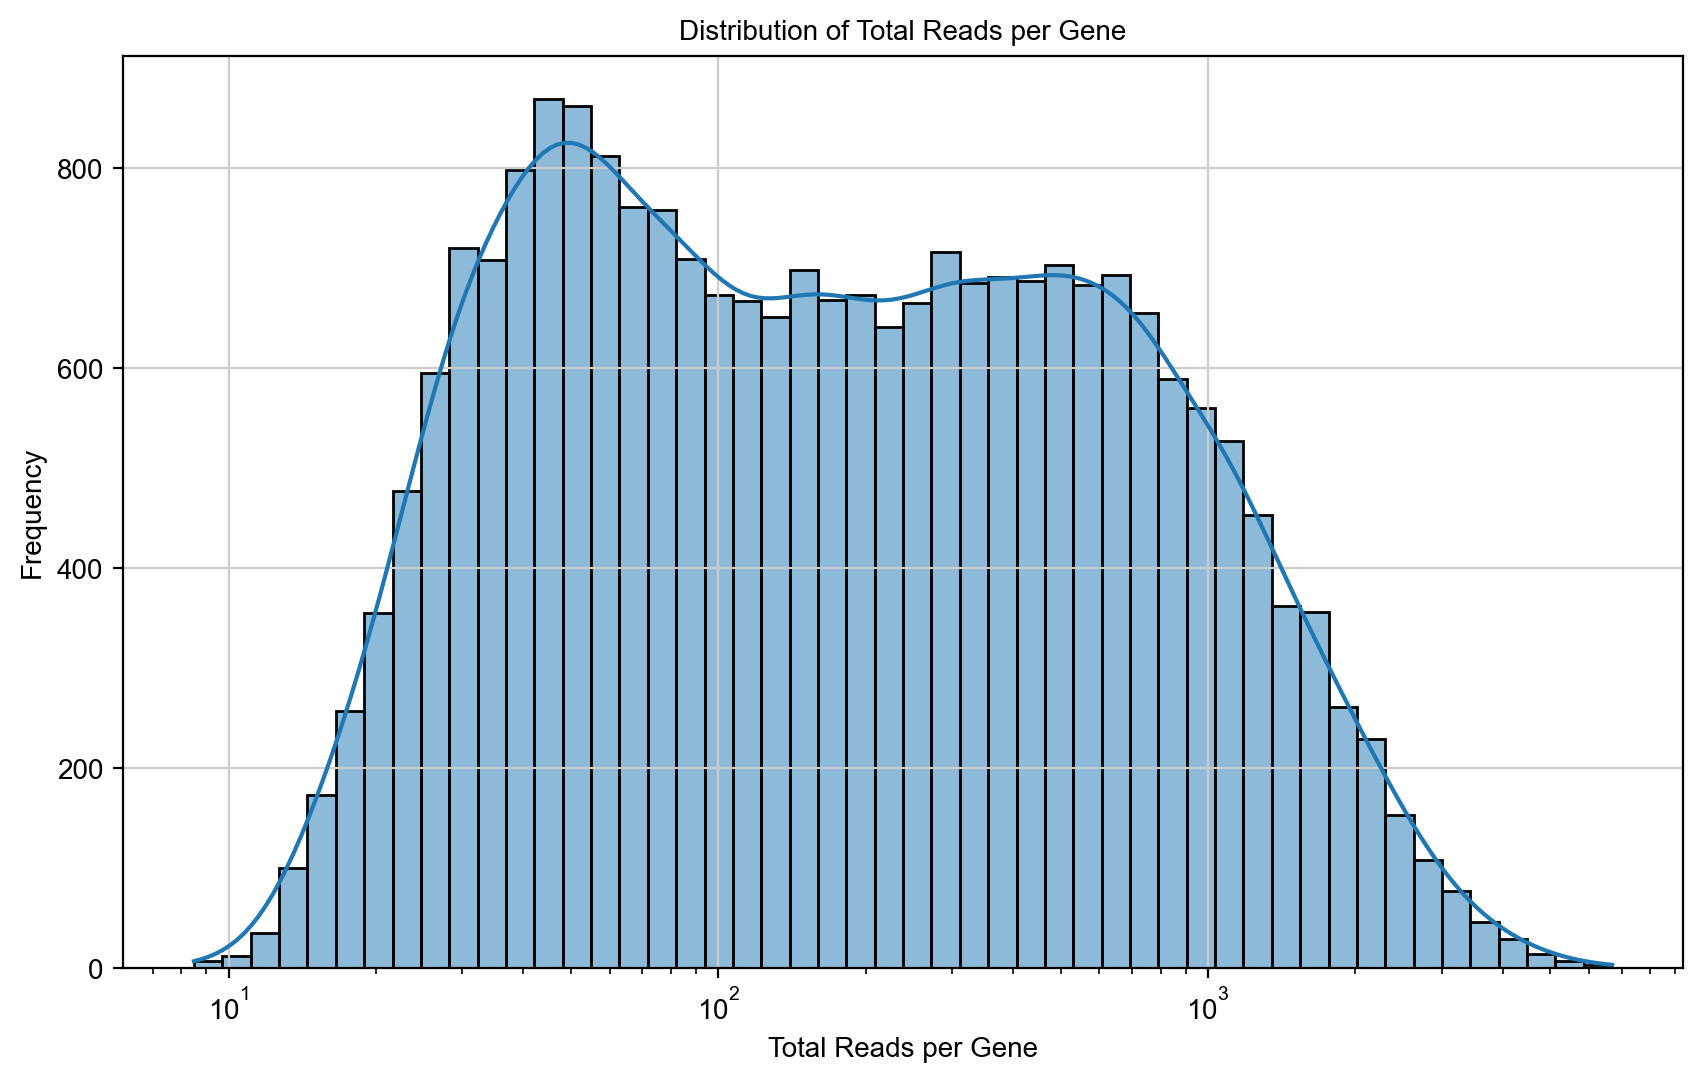

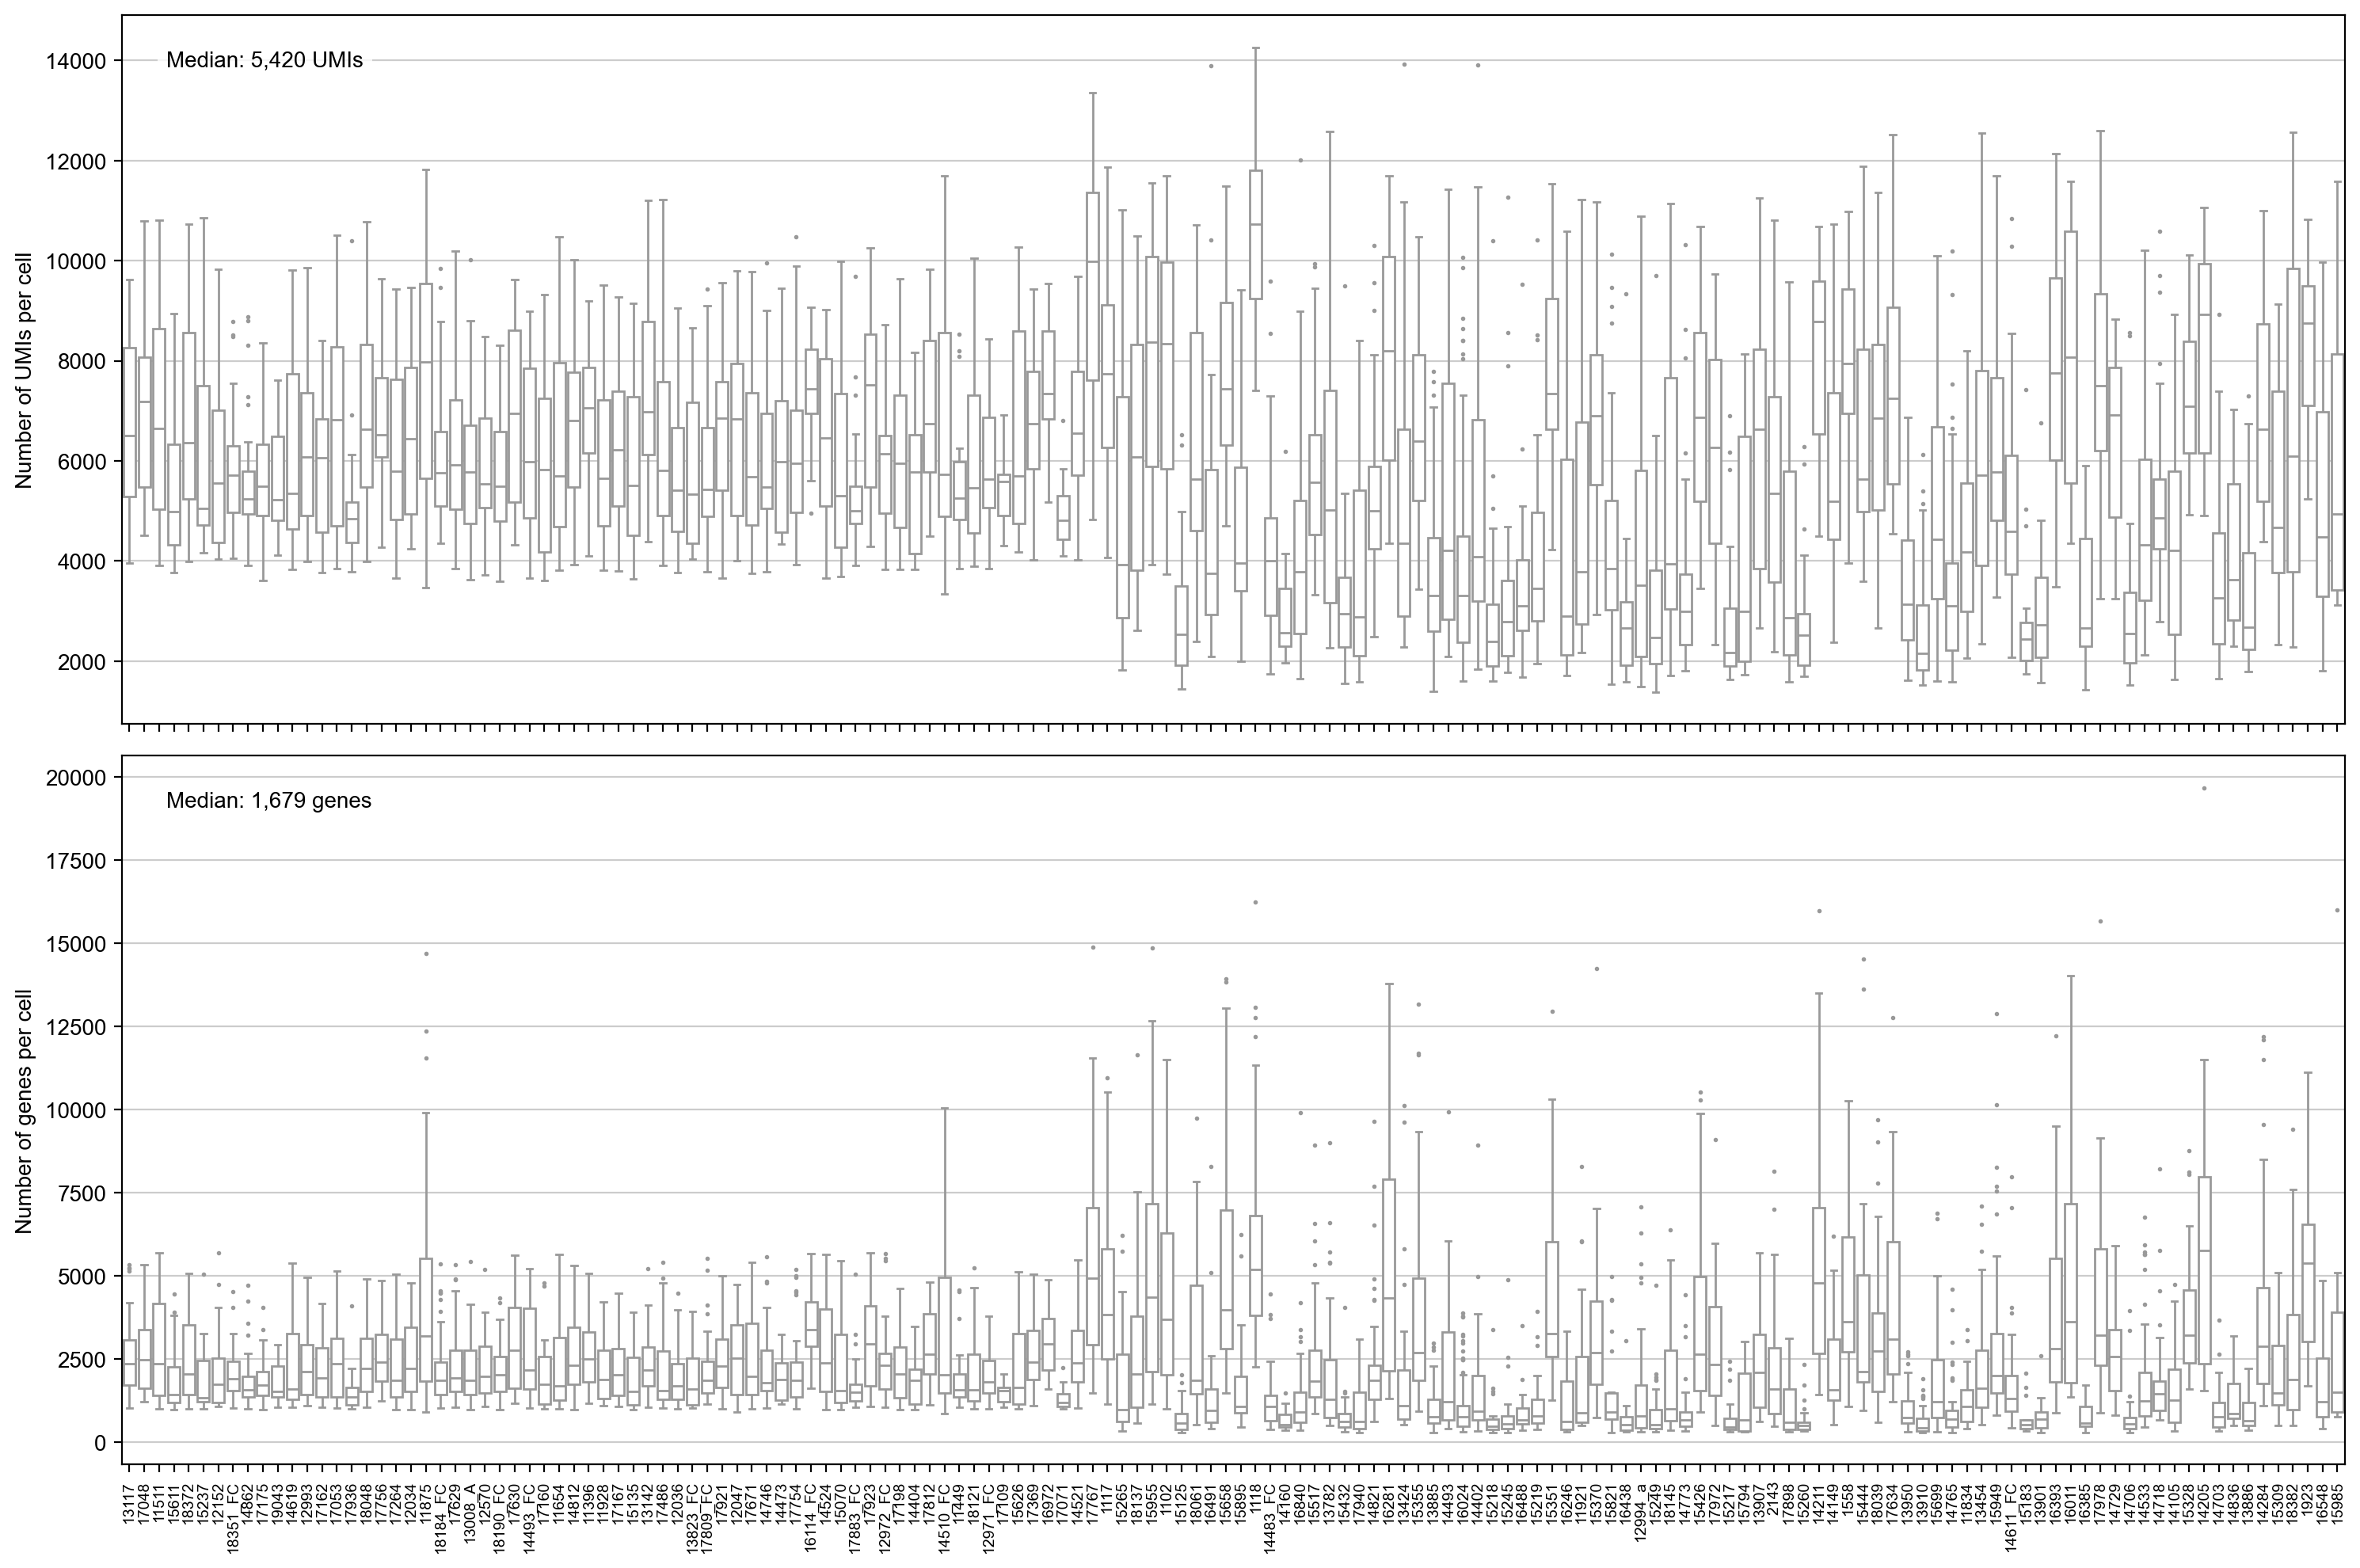

In [40]:
# Plot reads per gene distribution
plot_gene_read_distribution(adata)
plot_stacked_figure(adata, sample_column="sample", color_column='leiden_0.3', barplot=False)

Dataset dimensions: (5225, 587)
Filtering genes with min_reads=10 and min_samples=100.
Found 150 unique samples.
Sample mapping matrix constructed.
Sparse matrix aggregation completed.
Applying filtering criteria: minimum reads per sample and minimum samples per gene.
Number of genes passing the filter: 587 out of 587 total genes.


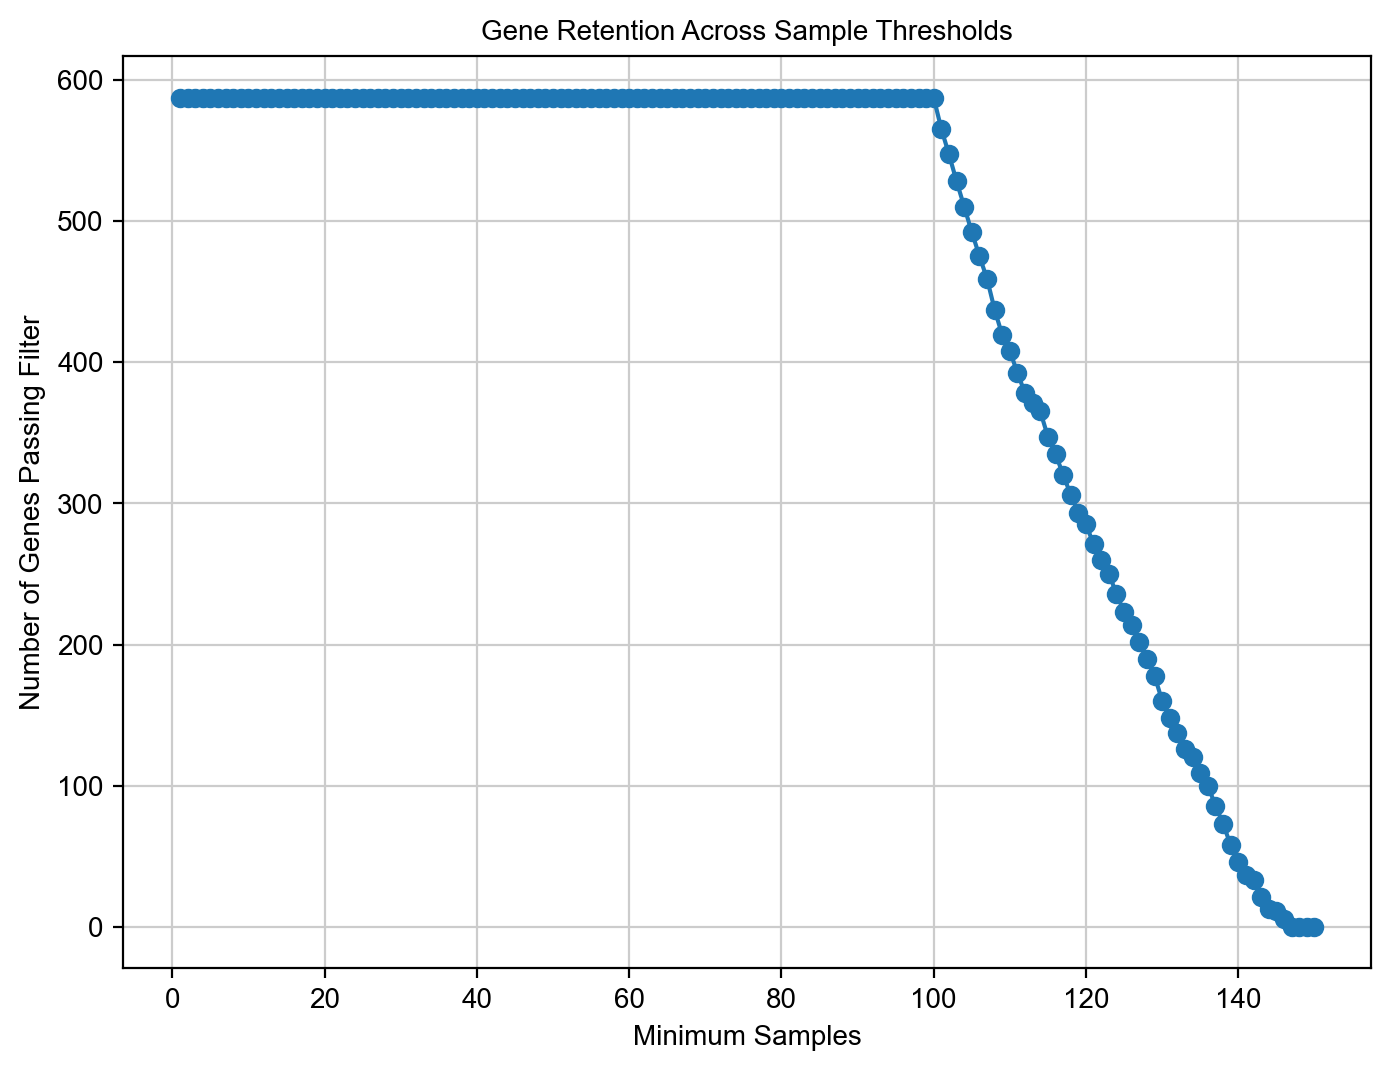

Filtering genes in place.
New dataset dimensions after filtering: (5225, 587)
Filtered genes when min reads=10, min_samples=100: 587 remain.



In [44]:
# Retain genes with at least min_reads in at least min_samples in the dataset
# Failed on min_reads=10, min_samples=100
#if run_genes_in_smpl_filter is True:
#    for min_reads in [1, 5, 10]:
#        for min_samples in [25, 50, 75, 100]:
#            mask = filter_genes_by_read_count(adata, min_reads=min_reads, min_samples=min_samples, inplace=False, verbose=True)
#            filtered_genes = adata.var.index[mask].tolist()
#            print(f"Filtered genes when min reads={min_reads}, min_samples={min_samples}: {len(filtered_genes)} remain.\n")
min_reads = 10
min_samples = 100
filter_genes_by_read_count(adata, min_reads=min_reads, min_samples=min_samples, inplace=True, verbose=True)
print(f"Filtered genes when min reads={min_reads}, min_samples={min_samples}: {adata.shape[1]} remain.\n")

# Recalculate QC metrics after filtering genes
#mt_genes = [gene for gene in adata.var_names if gene.upper().startswith("MT-")]
#print(f"Number of mitochondrial genes: {len(mt_genes)}")
sc.pp.calculate_qc_metrics(adata, inplace=True, log1p=True)

In [ ]:
# Plot reads per gene distribution
plot_gene_read_distribution(adata)
plot_stacked_figure(adata, sample_column="sample", color_column='leiden_0.3', barplot=False)

# Initial cell counts

In [25]:
# Cell counts by sample
print(f"Number of samples: {adata.obs['sample'].nunique()}")
adata.obs['sample'].value_counts()

Number of samples: 150


sample
16024       143
1118        116
14706       105
13910        90
15658        75
           ... 
19043        11
16972        10
12971_FC     10
17109         9
14521         8
Name: count, Length: 150, dtype: int64

In [26]:
# Cell counts by sublibrary
adata.obs['sublibrary'] = [x[1] for x in adata.obs.index.str.split('__s')] 
adata.obs['sublibrary'].value_counts()

sublibrary
1     390
3     374
6     369
2     361
10    342
12    332
7     330
5     328
15    325
8     323
4     319
14    313
11    312
9     310
13    304
16    193
Name: count, dtype: int64

In [27]:
#Cell counts by plate
adata.obs['plate'].value_counts()

plate
plate2    3462
plate1    1763
Name: count, dtype: int64

In [ ]:
adata.obs

sample species  gene_count  tscp_count  mread_count  \
bc_wells                                                                   
plate1_57_30_71__s6   13117    hg38        1043        1452         2370   
plate1_44_34_46__s14  17048    hg38        3948        9928        23585   
plate1_49_62_02__s2   11511    hg38        1462        2126         6108   
plate1_50_83_12__s15  15611    hg38        3299        7059        14267   
plate1_46_23_36__s5   18372    hg38        2281        4040         9706   
...                     ...     ...         ...         ...          ...   
plate2_20_04_41__s11  13424    hg38        2394        3978         8115   
plate2_54_80_45__s13  15265    hg38        2874        5373        12698   
plate2_52_24_03__s16  15249    hg38         459         582         1518   
plate2_12_79_82__s14   1102    hg38        3249        7926        23665   
plate2_26_44_77__s14  13910    hg38        1082        1497         4001   

                     leiden  n_genes_by_counts  log1p_n_genes_by_counts  \
bc_wells                                                                  
plate1_57_30_71__s6       1               1043                 6.950815   
plate1_44_34_46__s14      4               3948                 8.281218   
plate1_49_62_02__s2       3               1462                 7.288244   
plate1_50_83_12__s15      0               3299                 8.101678   
plate1_46_23_36__s5       6               2281                 7.732808   
...                     ...                ...                      ...   
plate2_20_04_41__s11     12               2394                 7.781139   
plate2_54_80_45__s13      0               2874                 7.963808   
plate2_52_24_03__s16      1                459                 6.131226   
plate2_12_79_82__s14      0               3249                 8.086410   
plate2_26_44_77__s14      5               1082                 6.987490   

                      total_counts  log1p_total_counts  ...  total_counts_hb  \
bc_wells                                                ...                    
plate1_57_30_71__s6    3954.378520            8.282832  ...         0.000000   
plate1_44_34_46__s14   9063.124751            9.112080  ...         0.000000   
plate1_49_62_02__s2    5375.231639            8.589743  ...         0.000000   
plate1_50_83_12__s15   7547.901036            8.929157  ...         0.000000   
plate1_46_23_36__s5    6528.936762            8.784153  ...         0.000000   
...                            ...                 ...  ...              ...   
plate2_20_04_41__s11   7207.586196            8.883028  ...         0.000000   
plate2_54_80_45__s13   7706.775436            8.949985  ...         0.000000   
plate2_52_24_03__s16   2080.338320            7.640766  ...         0.000000   
plate2_12_79_82__s14   7708.189648            8.950168  ...         9.157249   
plate2_26_44_77__s14   4262.092720            8.357750  ...         0.000000   

                      log1p_total_counts_hb  pct_counts_hb  n_genes  \
bc_wells                                                              
plate1_57_30_71__s6                0.000000       0.000000     1031   
plate1_44_34_46__s14               0.000000       0.000000     3745   
plate1_49_62_02__s2                0.000000       0.000000     1418   
plate1_50_83_12__s15               0.000000       0.000000     3193   
plate1_46_23_36__s5                0.000000       0.000000     2207   
...                                     ...            ...      ...   
plate2_20_04_41__s11               0.000000       0.000000     2394   
plate2_54_80_45__s13               0.000000       0.000000     2874   
plate2_52_24_03__s16               0.000000       0.000000      459   
plate2_12_79_82__s14               2.318188       0.118799     3249   
plate2_26_44_77__s14               0.000000       0.000000     1082   

                         n_counts  doublet_score  predicted_doublet  \
bc_wells            

In [29]:
# Normalise
logger.info("Normalising ...")
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

2025-01-24 07:42:52,143 - INFO - Normalising ...


normalizing counts per cell
    finished (0:00:00)


2025-01-24 07:42:52,186 - INFO - Detecting variable genes ...


extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)
... as `zero_center=True`, sparse input is densified and may lead to large memory consumption
    ... clipping at max_value 10


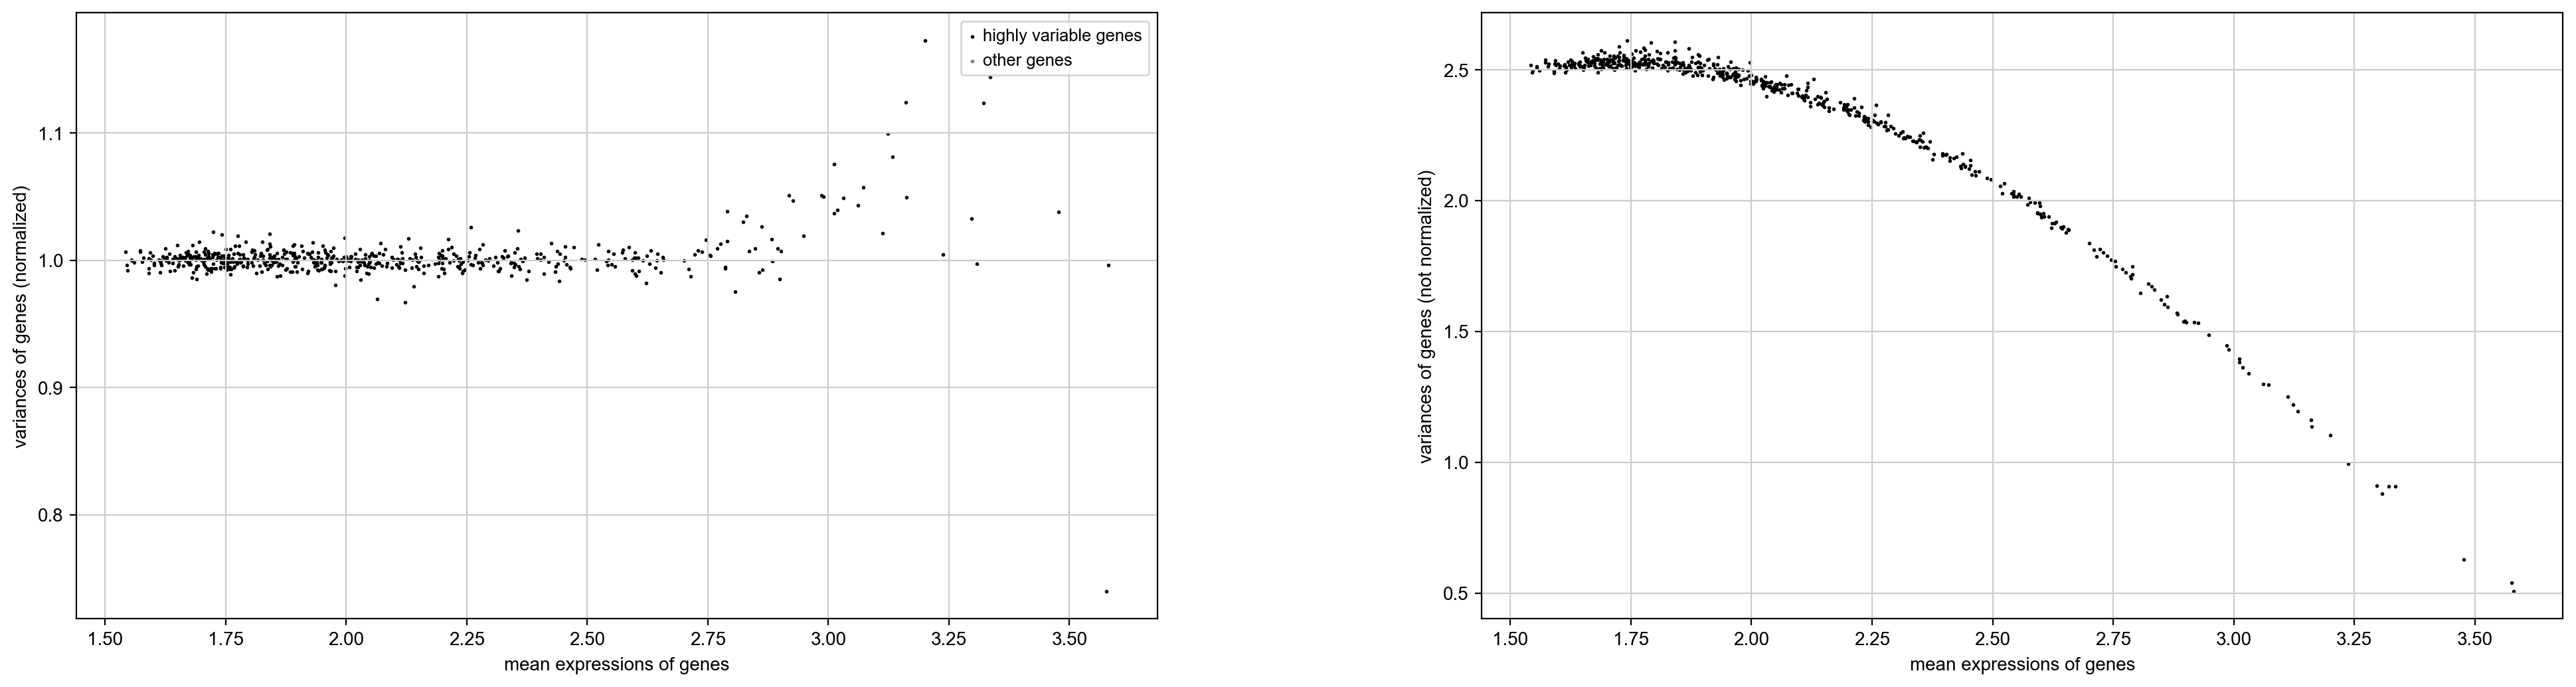

In [30]:
# Get highly variable genes
logger.info("Detecting variable genes ...")
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat_v3", batch_key=batch_col)
# This saves the original set of genes 
adata.raw = adata

adata = adata[:,adata.var.highly_variable]
sc.pp.scale(adata, max_value=10)
sc.pl.highly_variable_genes(adata)

hvg_genes = sorted(adata.var_names[adata.var['highly_variable']])
with open(scanpy_dir + "highly_variable_genes.txt", "w") as f:
    for gene in hvg_genes:
        f.write(f"{gene}\n")

2025-01-24 07:42:52,774 - INFO - PCA ...


computing PCA
    with n_comps=50
    finished (0:00:00)
    and added
    'X_pca', the PCA coordinates (adata.obs)
    'PCs', the loadings (adata.varm)
    'pca_variance', the variance / eigenvalues (adata.uns['pca'])
    'pca_variance_ratio', the variance ratio (adata.uns['pca'])


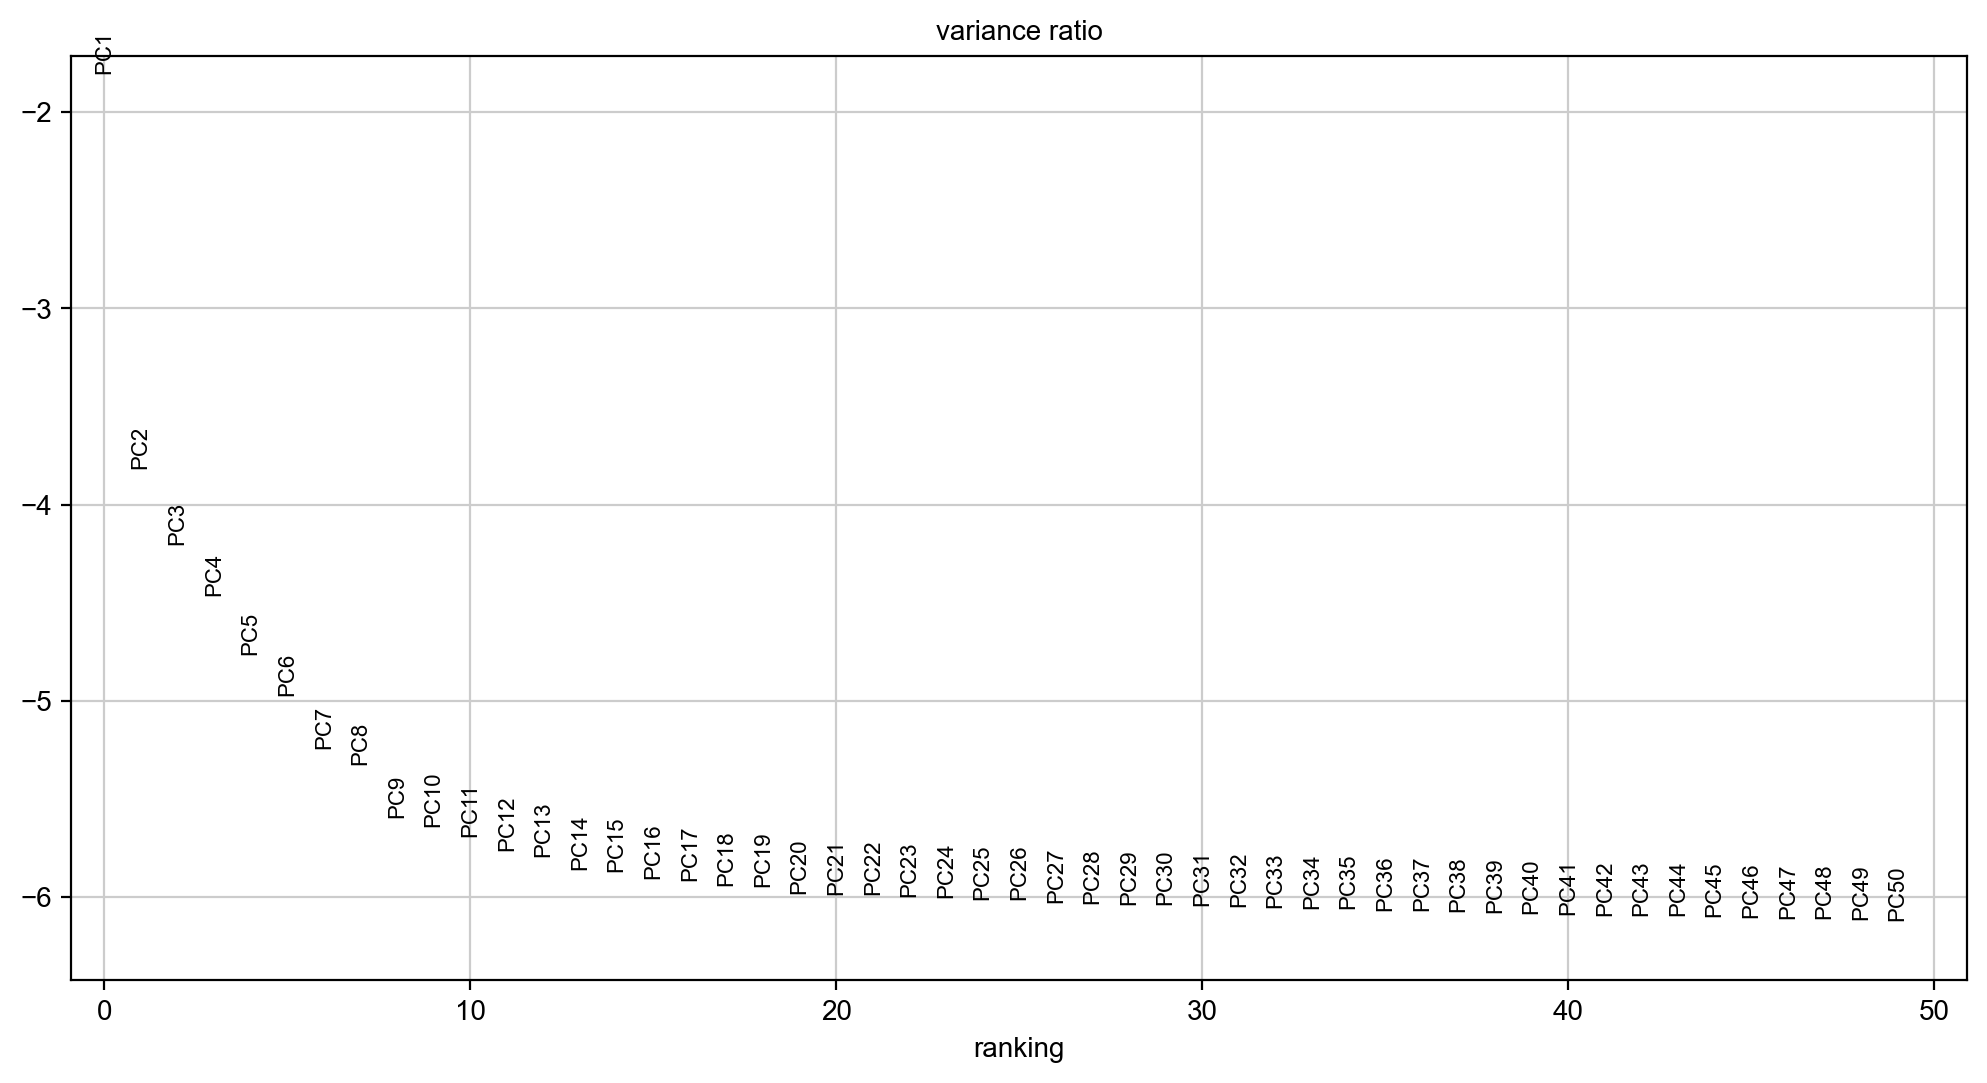

In [31]:
# PCA
logger.info("PCA ...")
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50, save='') # scanpy generates the filename automatically

In [ ]:
# Plotting
adata.obs

sample species  gene_count  tscp_count  mread_count  \
bc_wells                                                                   
plate1_57_30_71__s6   13117    hg38        1043        1452         2370   
plate1_44_34_46__s14  17048    hg38        3948        9928        23585   
plate1_49_62_02__s2   11511    hg38        1462        2126         6108   
plate1_50_83_12__s15  15611    hg38        3299        7059        14267   
plate1_46_23_36__s5   18372    hg38        2281        4040         9706   
...                     ...     ...         ...         ...          ...   
plate2_20_04_41__s11  13424    hg38        2394        3978         8115   
plate2_54_80_45__s13  15265    hg38        2874        5373        12698   
plate2_52_24_03__s16  15249    hg38         459         582         1518   
plate2_12_79_82__s14   1102    hg38        3249        7926        23665   
plate2_26_44_77__s14  13910    hg38        1082        1497         4001   

                     leiden  n_genes_by_counts  log1p_n_genes_by_counts  \
bc_wells                                                                  
plate1_57_30_71__s6       1               1043                 6.950815   
plate1_44_34_46__s14      4               3948                 8.281218   
plate1_49_62_02__s2       3               1462                 7.288244   
plate1_50_83_12__s15      0               3299                 8.101678   
plate1_46_23_36__s5       6               2281                 7.732808   
...                     ...                ...                      ...   
plate2_20_04_41__s11     12               2394                 7.781139   
plate2_54_80_45__s13      0               2874                 7.963808   
plate2_52_24_03__s16      1                459                 6.131226   
plate2_12_79_82__s14      0               3249                 8.086410   
plate2_26_44_77__s14      5               1082                 6.987490   

                      total_counts  log1p_total_counts  ...  total_counts_hb  \
bc_wells                                                ...                    
plate1_57_30_71__s6    3954.378520            8.282832  ...         0.000000   
plate1_44_34_46__s14   9063.124751            9.112080  ...         0.000000   
plate1_49_62_02__s2    5375.231639            8.589743  ...         0.000000   
plate1_50_83_12__s15   7547.901036            8.929157  ...         0.000000   
plate1_46_23_36__s5    6528.936762            8.784153  ...         0.000000   
...                            ...                 ...  ...              ...   
plate2_20_04_41__s11   7207.586196            8.883028  ...         0.000000   
plate2_54_80_45__s13   7706.775436            8.949985  ...         0.000000   
plate2_52_24_03__s16   2080.338320            7.640766  ...         0.000000   
plate2_12_79_82__s14   7708.189648            8.950168  ...         9.157249   
plate2_26_44_77__s14   4262.092720            8.357750  ...         0.000000   

                      log1p_total_counts_hb  pct_counts_hb  n_genes  \
bc_wells                                                              
plate1_57_30_71__s6                0.000000       0.000000     1031   
plate1_44_34_46__s14               0.000000       0.000000     3745   
plate1_49_62_02__s2                0.000000       0.000000     1418   
plate1_50_83_12__s15               0.000000       0.000000     3193   
plate1_46_23_36__s5                0.000000       0.000000     2207   
...                                     ...            ...      ...   
plate2_20_04_41__s11               0.000000       0.000000     2394   
plate2_54_80_45__s13               0.000000       0.000000     2874   
plate2_52_24_03__s16               0.000000       0.000000      459   
plate2_12_79_82__s14               2.318188       0.118799     3249   
plate2_26_44_77__s14               0.000000       0.000000     1082   

                         n_counts  doublet_score  predicted_doublet  \
bc_wells            

In [33]:
# UMAP and Clustering
logger.info("Clustering and UMAP ...")
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=30)
sc.tl.umap(adata)

for res in resolutions:
    sc.tl.leiden(adata, resolution=res, key_added=f'leiden_{res}')

2025-01-24 07:42:54,288 - INFO - Clustering and UMAP ...


computing neighbors
    computing neighbors
    using 'X_pca' with n_pcs = 30
    computed neighbors (0:00:00)
    computed connectivities (0:00:00)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP


  0%|          | 0/500 [00:00<?, ?it/s]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:05)
running Leiden clustering
    finished: found 6 clusters and added
    'leiden_0.3', the cluster labels (adata.obs, categorical) (0:00:00)


2025-01-24 07:43:00,602 - INFO - Plot UMAP ...
... storing 'sample' as categorical
... storing 'plate' as categorical
... storing 'sublibrary' as categorical


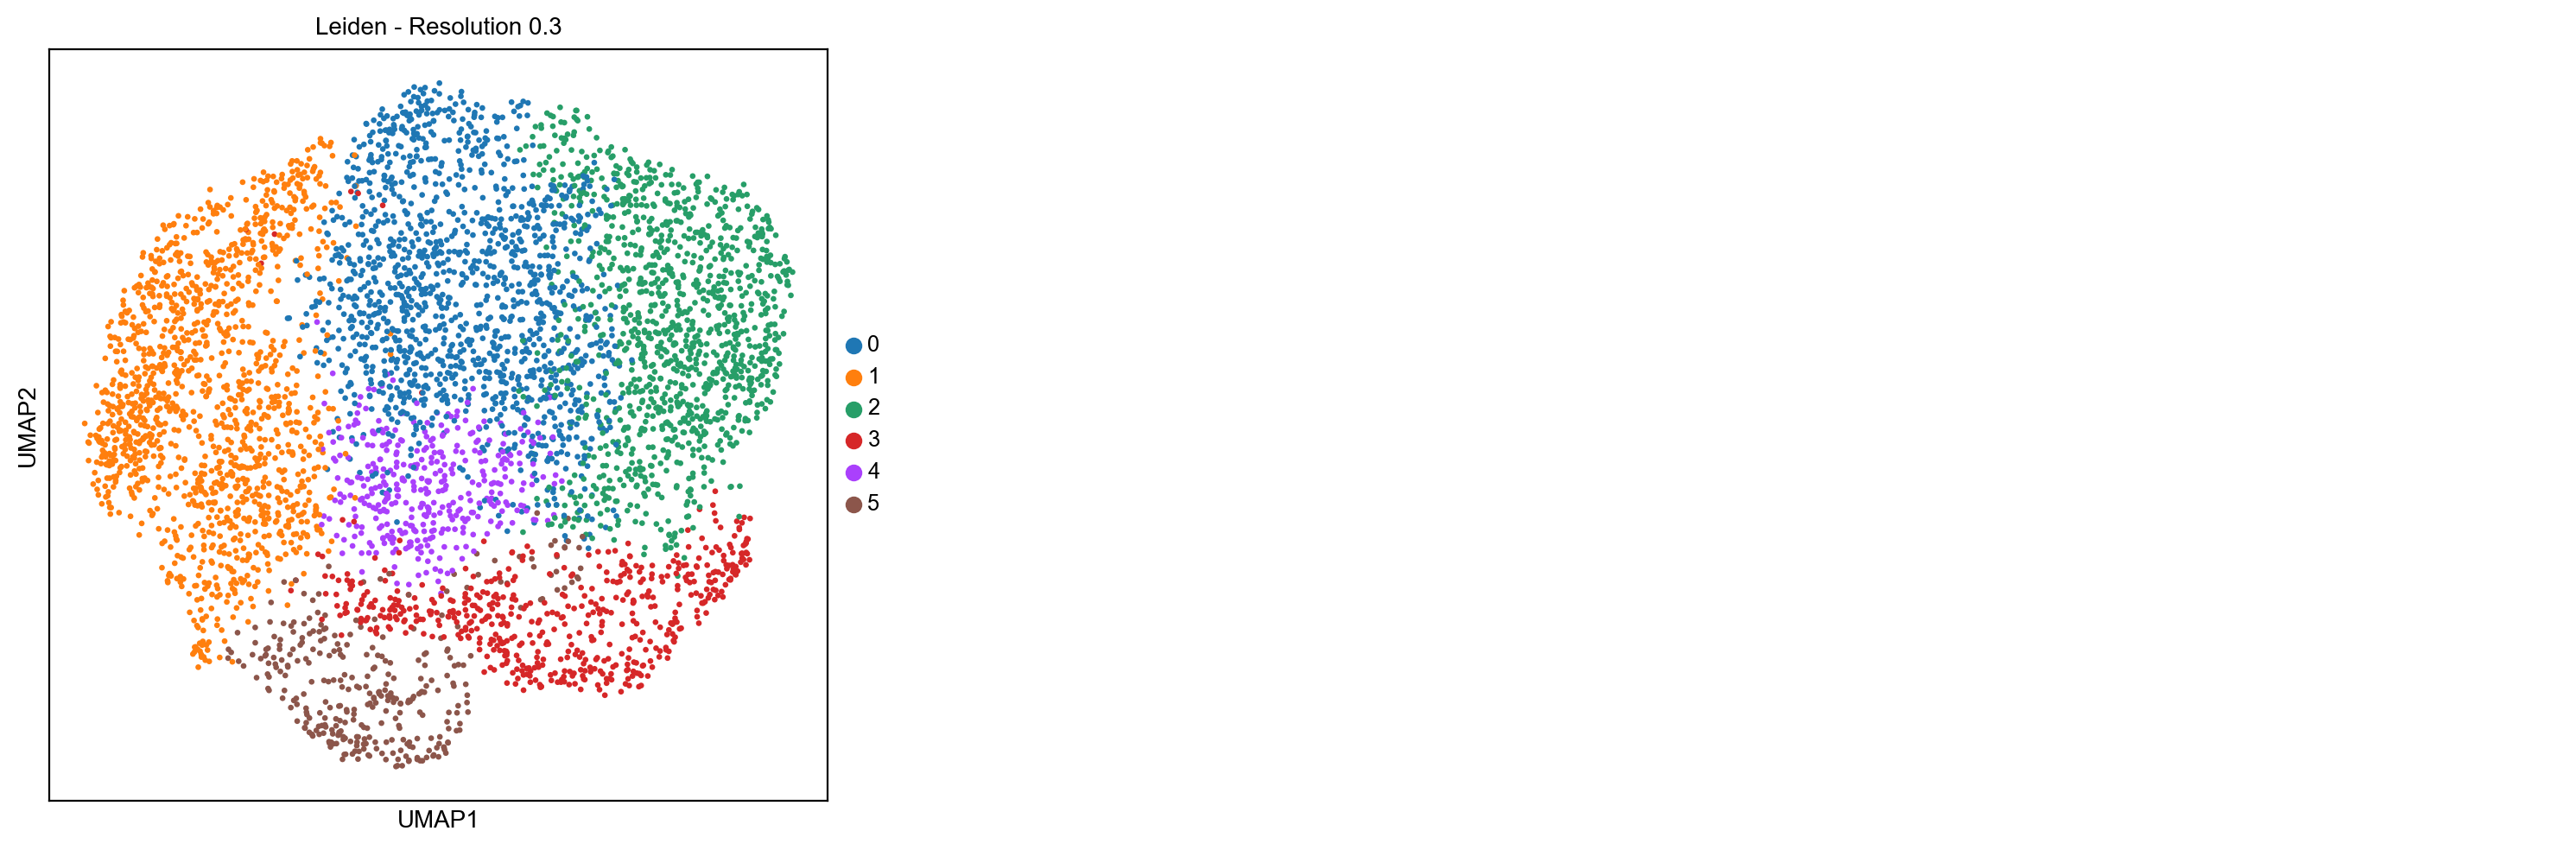

In [34]:
# Helper function
logger.info("Plot UMAP ...")
#create_umap_visualisations(adata, resolutions, leiden_prefix="leiden")

fig = create_umap_visualisations(adata, resolutions, leiden_prefix="leiden", clustering_algorithm="Leiden")
plt.show() 

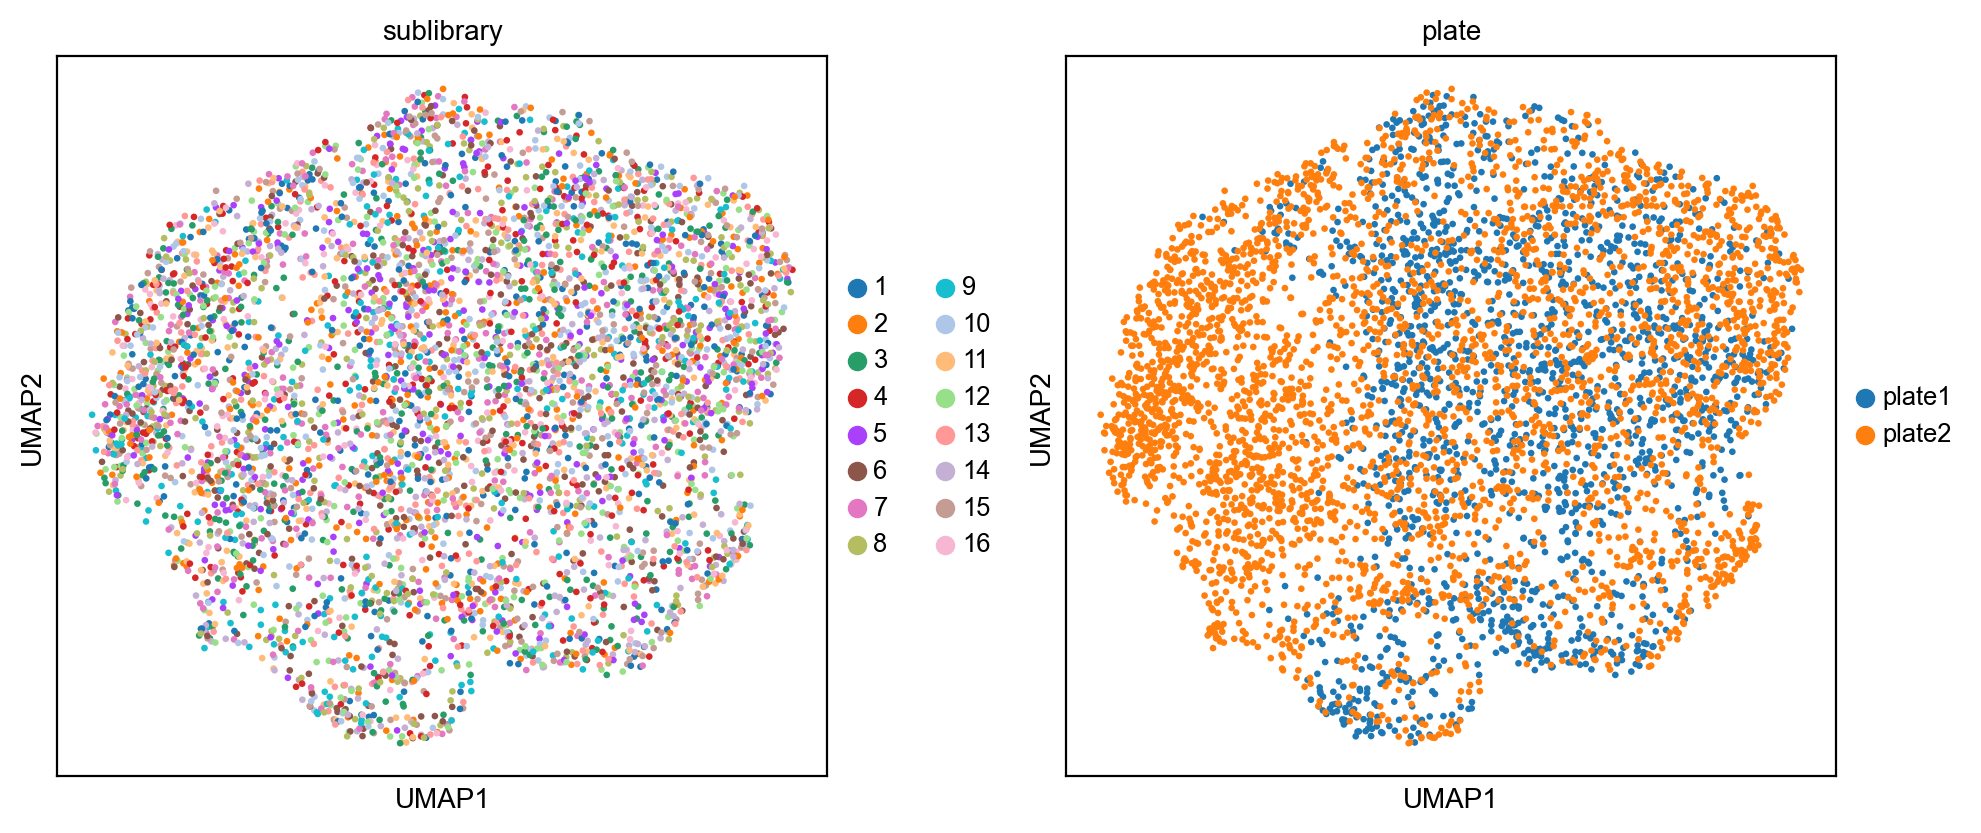

In [ ]:
# UMAPs by .obs column
obs_columns = ['sublibrary', 'plate']
plot_umap_grid(adata, obs_columns, grid_size=(2, 2), figsize=(10, 8), save_path=None)

In [ ]:
# Harmony
#sce.pp.harmony_integrate(adata, 'plate')
##'X_pca_harmony' in adata.obsm
#adata.obsm['X_pca'] = adata.obsm['X_pca_harmony']
#sc.pp.neighbors(adata, n_neighbors=10, n_pcs=30)
#sc.tl.umap(adata)
#sc.tl.leiden(adata, resolution=0.5)

# Annotation

In [ ]:
# Violin plots
logger.info("Plot Violin 1 ...")
gene_sets = [
    ("general_genes", general_genes)
]

# Need to get rid of infor warnings and tweak plts
fig, axes = plot_filtered_violin(
    adata, 
    gene_sets, 
    groupby_base="leiden", 
    resolutions=resolutions, 
    clustering_algorithm="Leiden")
plt.show()  # Display the figure

2025-01-24 07:43:01,811 - INFO - Plot Violin 1 ...


Genes not found in dataset for gene set general_genes: SLC17A7, SLC17A6, SLC17A8, SLC6A1, SLC6A13, SLC6A11, SLC6A12, SST, NPY, GAD1, GAD2, PVALB, CALB2, VIP, C3, C1QB, AQP4, SOX9, GFAP, OLIG1, OLIG2, MBP, PDGRFA, PMP2, EOMES, EBF1, ABCB1
None of the genes in the provided gene sets are present in the dataset.


TypeError: cannot unpack non-iterable NoneType object

In [ ]:
logger.info("Plot Violin 2 ...")
gene_sets = [
    ("general_genes", general_genes),
    ("pfc_features", pfc_features)
]

fig = plot_filtered_violin(
    adata, 
    gene_sets, 
    groupby_base="leiden", 
    resolutions=resolutions, 
    clustering_algorithm="Leiden")
plt.show()  # Display the figure

In [ ]:
# Plot sample per cluster
# Function saves an excel file with the cell counts per sample per cluster 
# Extract sample and leiden cluster information from the AnnData object
fig = plot_and_save_cluster_percentages(
    adata=adata,
    output_dir = scanpy_dir,
    clustering_param="leiden_0.3"
)
plt.show() 


In [ ]:
plot_stacked_figure(adata, sample_column="sample", color_column="leiden_0.3", barplot=True)

In [ ]:
adata.obs[['total_counts', 'n_counts', 'n_genes']]

In [ ]:
logger.info("Saving h5ad file ...")
adata.write(scanpy_dir + f'adata_clusters.h5ad')
logger.info("All done.")